In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import layers

### Loading the Mnist dataset 

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

## Shapes of training and testing dataset

In [3]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [4]:
# each image is of 28*28 matrix and 60k data fro train and 10k data for testing

## Data Normalization

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [9]:
## pixels range from 0 to 255  0 -> BLACK 255 -> IS WHITE

In [7]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [8]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [10]:
##(batch_size, height, width, channels)  -> GRAYSCALE IMAGE SO ONLY 1 CHANNEL

## Building a Cnn model

In [15]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([

    keras.Input(shape=(28,28,1)), ## defines an input shape

    layers.Conv2D(32, (3,3), activation='relu'), ## 32 filters in this 1st convolution layer 

    layers.MaxPooling2D((2,2)), ## reduce image size by half 

    layers.Conv2D(64, (3,3), activation='relu'), ## 64 filters in 2nd convolution layer 

    layers.MaxPooling2D((2,2)), ## reduces size again 

    layers.Flatten(), # convert from 2D -> 1D vector 

    layers.Dense(64, activation='relu'), ## fully connected Layer 

    layers.Dense(10, activation='softmax') ## Output layer with 10 outputs with nums 0-9
])

In [16]:
model.compile(
    optimizer='adam', ## improves weight automatically 
    loss='sparse_categorical_crossentropy', ## Measures error between prediction and true label.
    metrics=['accuracy'] ## eval metrics is accuracy 
)

## Model Training

In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=5, # 1 full pass of dataset , 5 means model sees the dataset 5 times 
    validation_split=0.1 ## 10 percent is used for testing
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9551 - loss: 0.1467 - val_accuracy: 0.9862 - val_loss: 0.0483
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9849 - loss: 0.0488 - val_accuracy: 0.9887 - val_loss: 0.0423
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9898 - loss: 0.0335 - val_accuracy: 0.9890 - val_loss: 0.0391
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9921 - loss: 0.0245 - val_accuracy: 0.9905 - val_loss: 0.0339
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9941 - loss: 0.0181 - val_accuracy: 0.9912 - val_loss: 0.0353


## Model Evalutation

In [18]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9916 - loss: 0.0282


[0.028166357427835464, 0.991599977016449]

## Making predictions 

In [19]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [20]:
predictions

array([[3.18633425e-10, 2.32520364e-10, 7.83125031e-08, ...,
        9.99999762e-01, 1.06978595e-08, 7.11698362e-08],
       [6.65377854e-07, 5.14512658e-06, 9.99981940e-01, ...,
        7.78362513e-11, 3.06407024e-08, 4.60466859e-10],
       [4.79335931e-08, 9.99877572e-01, 3.87322928e-07, ...,
        2.07403700e-05, 2.44673811e-06, 3.67617616e-07],
       ...,
       [5.27731384e-16, 1.83635798e-11, 5.65445247e-14, ...,
        8.65679695e-10, 1.23453162e-07, 3.61238095e-10],
       [1.58335723e-11, 2.60825602e-14, 1.82376643e-13, ...,
        2.30551824e-13, 1.45171152e-05, 1.91102190e-12],
       [1.59682756e-08, 6.11662554e-10, 7.57042571e-08, ...,
        2.25517109e-12, 1.60820388e-08, 3.78616960e-09]],
      shape=(10000, 10), dtype=float32)

In [21]:
## gives probabilities instead of actual predictions

In [22]:
#for the first image , predcition : 
predictions[0]

array([3.18633425e-10, 2.32520364e-10, 7.83125031e-08, 5.72509506e-08,
       5.52418286e-14, 3.77907128e-09, 3.84144620e-13, 9.99999762e-01,
       1.06978595e-08, 7.11698362e-08], dtype=float32)

In [23]:
predicted_label = np.argmax(predictions[0])

In [24]:
predicted_label

np.int64(7)

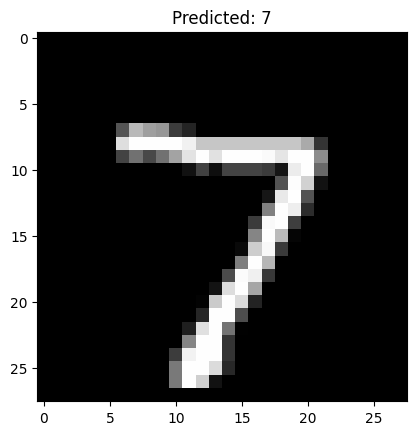

In [25]:
plt.imshow(X_test[0].reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {predicted_label}")
plt.show()

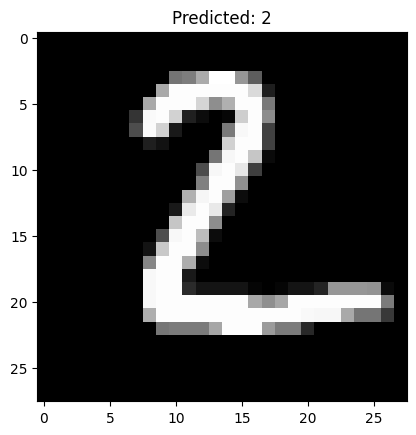

In [27]:
pred_lab =  np.argmax(predictions[1])
plt.imshow(X_test[1].reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {pred_lab}")
plt.show()

In [28]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,792 (1.40 MB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 243,862 (952.59 KB)